# Pump Sensor Anomaly Detection
## Single-file Pipeline: EDA → Preprocessing → Model Comparison → Auto-Tuning → LLM → Gradio

**실행 환경**: Kaggle Notebook (T4 GPU 권장)  
**데이터셋**: `pump-sensor-data` — 52 sensors, ~220K rows  
**실행 방법**: Run All (Shift+F5) — 전체 자동 실행, 외부 파일 의존 없음

| Section | 내용 |
|---------|------|
| 0 | 설치 + Config |
| 1 | 데이터 로드 |
| 2 | 깊은 EDA (7종 시각화) |
| 3 | VIF 다중공선성 제거 + 피처 확정 |
| 4 | 전처리 + Sliding Window |
| 5 | 모델 정의 (5종) |
| 6 | 전체 학습 + 자동 최선 모델 선정 |
| 7 | Optuna 자동 튜닝 (선정 모델만) |
| 8 | 최종 재학습 + 평가 |
| 9 | LLM 리포트 + Gradio UI |

---
## Section 0. Install & Config

In [1]:
# ─────────────────────────────────────────────────────────────────
#  INSTALL & IMPORTS
# ─────────────────────────────────────────────────────────────────
import subprocess, sys
import os, time, warnings, pickle, copy, random

pkgs = ['statsmodels', 'optuna', 'gradio', 'openai']
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split

import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import gradio as gr
import openai

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────────────────────────────
#  CONFIG
# [FLAG] TUNING_MODE
#  True  : Optuna 튜닝 단계 — 속도 최우선 (benchmark=True)
#  False : 최종 A/B 평가 단계 — 재현성 최우선 (deterministic=True)
# ─────────────────────────────────────────────────────────────────
TUNING_MODE = True

DATA_PATH = None
base_path = '/kaggle/input'
for root, dirs, files in os.walk(base_path):
    if 'sensor.csv' in files:
        DATA_PATH = os.path.join(root, 'sensor.csv')
        break

if DATA_PATH is None:
    raise FileNotFoundError('sensor.csv를 찾을 수 없습니다. 데이터셋이 추가되었는지 확인하세요.')

OUTPUT_DIR = '/kaggle/working/figures'
MODEL_DIR  = '/kaggle/working/models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

# ── 전처리 파라미터
WINDOW_SIZE    = 50
STEP_SIZE      = 10
SCALER_TYPE    = 'minmax'
THRESHOLD_PCT  = 95

# ★ VIF Optimized 컷오프
MISSING_THRESH = 0.50
VIF_THRESH     = 50.0
CORR_THRESH    = 0.98

# ── 기본 학습 파라미터
DEFAULT_HIDDEN  = 64
DEFAULT_LATENT  = 32
DEFAULT_LAYERS  = 2
DEFAULT_DROPOUT = 0.1
DEFAULT_LR      = 1e-3
DEFAULT_BATCH   = 64
DEFAULT_EPOCHS  = 100
OPTUNA_TRIALS   = 500

# ── 시드 고정
SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    if TUNING_MODE:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark     = True   # 속도 최우선
    else:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False  # 재현성 최우선

print(f'Mode   : {"TUNING (속도 최우선)" if TUNING_MODE else "EVALUATION (재현성 최우선)"}')
print(f'Device : {device}')
print(f'Data   : {DATA_PATH}')
print('Config OK.')


Mode   : TUNING (속도 최우선)
Device : cuda
Data   : /kaggle/input/datasets/nphantawee/pump-sensor-data/sensor.csv
Config OK.


In [2]:
# ─────────────────────────────────────────────────────────────────
#  검증 (Validation) 셀
# ─────────────────────────────────────────────────────────────────
import os

# 1. 파일 경로 확인
if DATA_PATH and os.path.exists(DATA_PATH):
    print(f"✅ 파일 탐색 성공: {DATA_PATH}")
    
    # 2. 데이터 로드 테스트
    try:
        df_check = pd.read_csv(DATA_PATH, nrows=5) # 5줄만 로드
        print(f"✅ 데이터 읽기 성공! Shape (샘플): {df_check.shape}")
        
        # 3. 필수 컬럼 존재 확인 (sensor_00 ~ sensor_51, machine_status)
        cols = df_check.columns.tolist()
        sensor_count = len([c for c in cols if 'sensor' in c])
        has_status = 'machine_status' in cols
        
        print(f"📊 센서 컬럼 개수: {sensor_count}개")
        print(f"📊 레이블(machine_status) 존재: {'YES' if has_status else 'NO'}")
        
        # 4. 데이터 샘플 출력
        print("\n=== 데이터 상위 3행 샘플 ===")
        display(df_check.head(3))
        
    except Exception as e:
        print(f"❌ 데이터 읽기 실패: {e}")
else:
    print(f"❌ 파일을 찾을 수 없습니다. 경로를 확인하세요: {DATA_PATH}")

# 5. 디바이스 및 출력 경로 재확인
print(f"\n💻 실행 디바이스: {device}")
print(f"📂 모델 저장 경로: {MODEL_DIR}")

✅ 파일 탐색 성공: /kaggle/input/datasets/nphantawee/pump-sensor-data/sensor.csv
✅ 데이터 읽기 성공! Shape (샘플): (5, 55)
📊 센서 컬럼 개수: 52개
📊 레이블(machine_status) 존재: YES

=== 데이터 상위 3행 샘플 ===


,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.39757,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL



💻 실행 디바이스: cuda
📂 모델 저장 경로: /kaggle/working/models


---
## Section 1. Data Load

In [3]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()

# 타임스탬프 컬럼 자동 감지
ts_col = next((c for c in df_raw.columns if 'time' in c.lower()), None)
if ts_col:
    df_raw.rename(columns={ts_col: 'timestamp'}, inplace=True)
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
    df_raw = df_raw.set_index('timestamp').sort_index()

sensor_cols = [c for c in df_raw.columns if c.startswith('sensor')]

print(f'Shape         : {df_raw.shape}')
print(f'Sensor cols   : {len(sensor_cols)}')
print(f'Date range    : {df_raw.index.min()} ~ {df_raw.index.max()}')
print(f'\nmachine_status counts:')
print(df_raw['machine_status'].value_counts())
df_raw.head(3)

Shape         : (220320, 54)
Sensor cols   : 52
Date range    : 2018-04-01 00:00:00 ~ 2018-08-31 23:59:00

machine_status counts:
machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64


,Unnamed: 0,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:01:00,1,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:02:00,2,2.444734,47.35243,53.2118,46.39757,638.8889,73.54598,13.32465,16.03733,15.61777,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL


---
## Section 2. Deep EDA
> 7종 시각화: 결측률 / 레이블분포 / 시계열전체 / 정상vs고장분포 / ADF정상성 / 상관행렬 / PCA

### 2-1. Missing rate + Label distribution

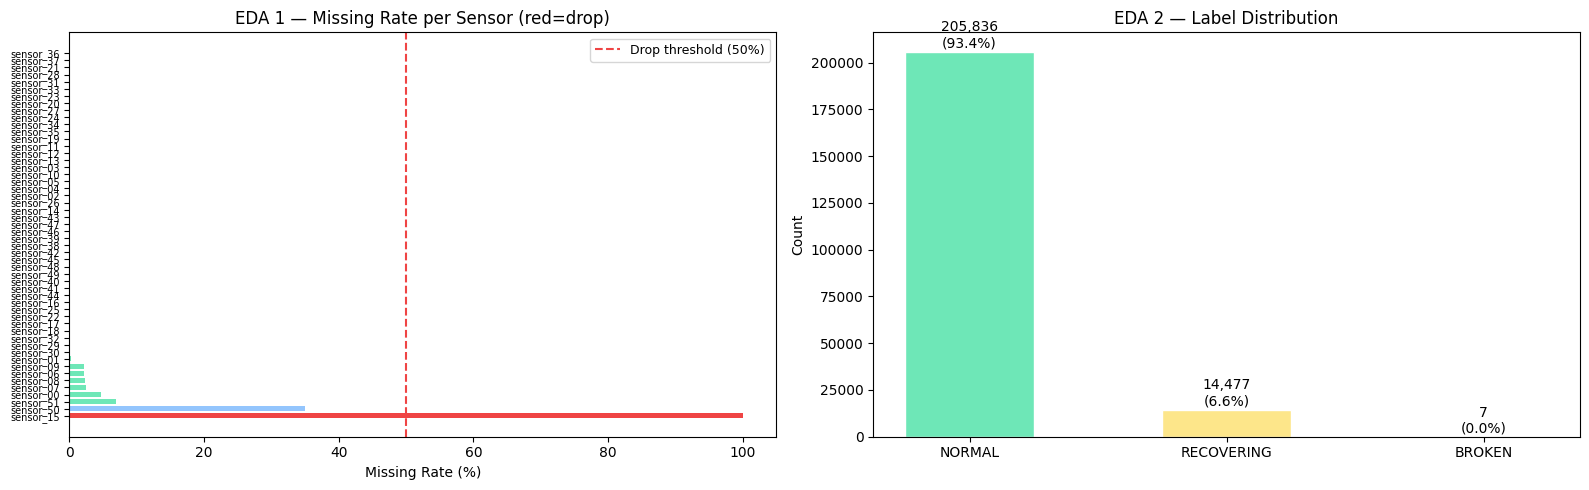

Dropped by missing: ['sensor_15']
Remaining sensors : 51


In [4]:
missing = df_raw[sensor_cols].isnull().mean().sort_values(ascending=False)
drop_missing = missing[missing > MISSING_THRESH].index.tolist()
valid_sensors = [c for c in sensor_cols if c not in drop_missing]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 결측률 바차트
ax = axes[0]
colors = ['#EF4444' if v > MISSING_THRESH else '#93C5FD' if v > 0.2 else '#6EE7B7'
          for v in missing.values]
ax.barh(missing.index, missing.values * 100, color=colors, height=0.7)
ax.axvline(MISSING_THRESH * 100, color='#EF4444', linestyle='--', lw=1.5,
           label=f'Drop threshold ({int(MISSING_THRESH*100)}%)')
ax.set_xlabel('Missing Rate (%)')
ax.set_title('EDA 1 — Missing Rate per Sensor (red=drop)')
ax.legend(fontsize=9)
ax.tick_params(axis='y', labelsize=7)

# 레이블 분포
vc = df_raw['machine_status'].value_counts()
bar_col = {'NORMAL':'#6EE7B7', 'BROKEN':'#FCA5A5', 'RECOVERING':'#FDE68A'}
ax2 = axes[1]
ax2.bar(vc.index, vc.values,
        color=[bar_col.get(k,'#CBD5E1') for k in vc.index], edgecolor='white', width=0.5)
for i,(k,v) in enumerate(vc.items()):
    ax2.text(i, v+500, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)
ax2.set_title('EDA 2 — Label Distribution')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_missing_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dropped by missing: {drop_missing}')
print(f'Remaining sensors : {len(valid_sensors)}')

### 2-2. Full time series — all valid sensors

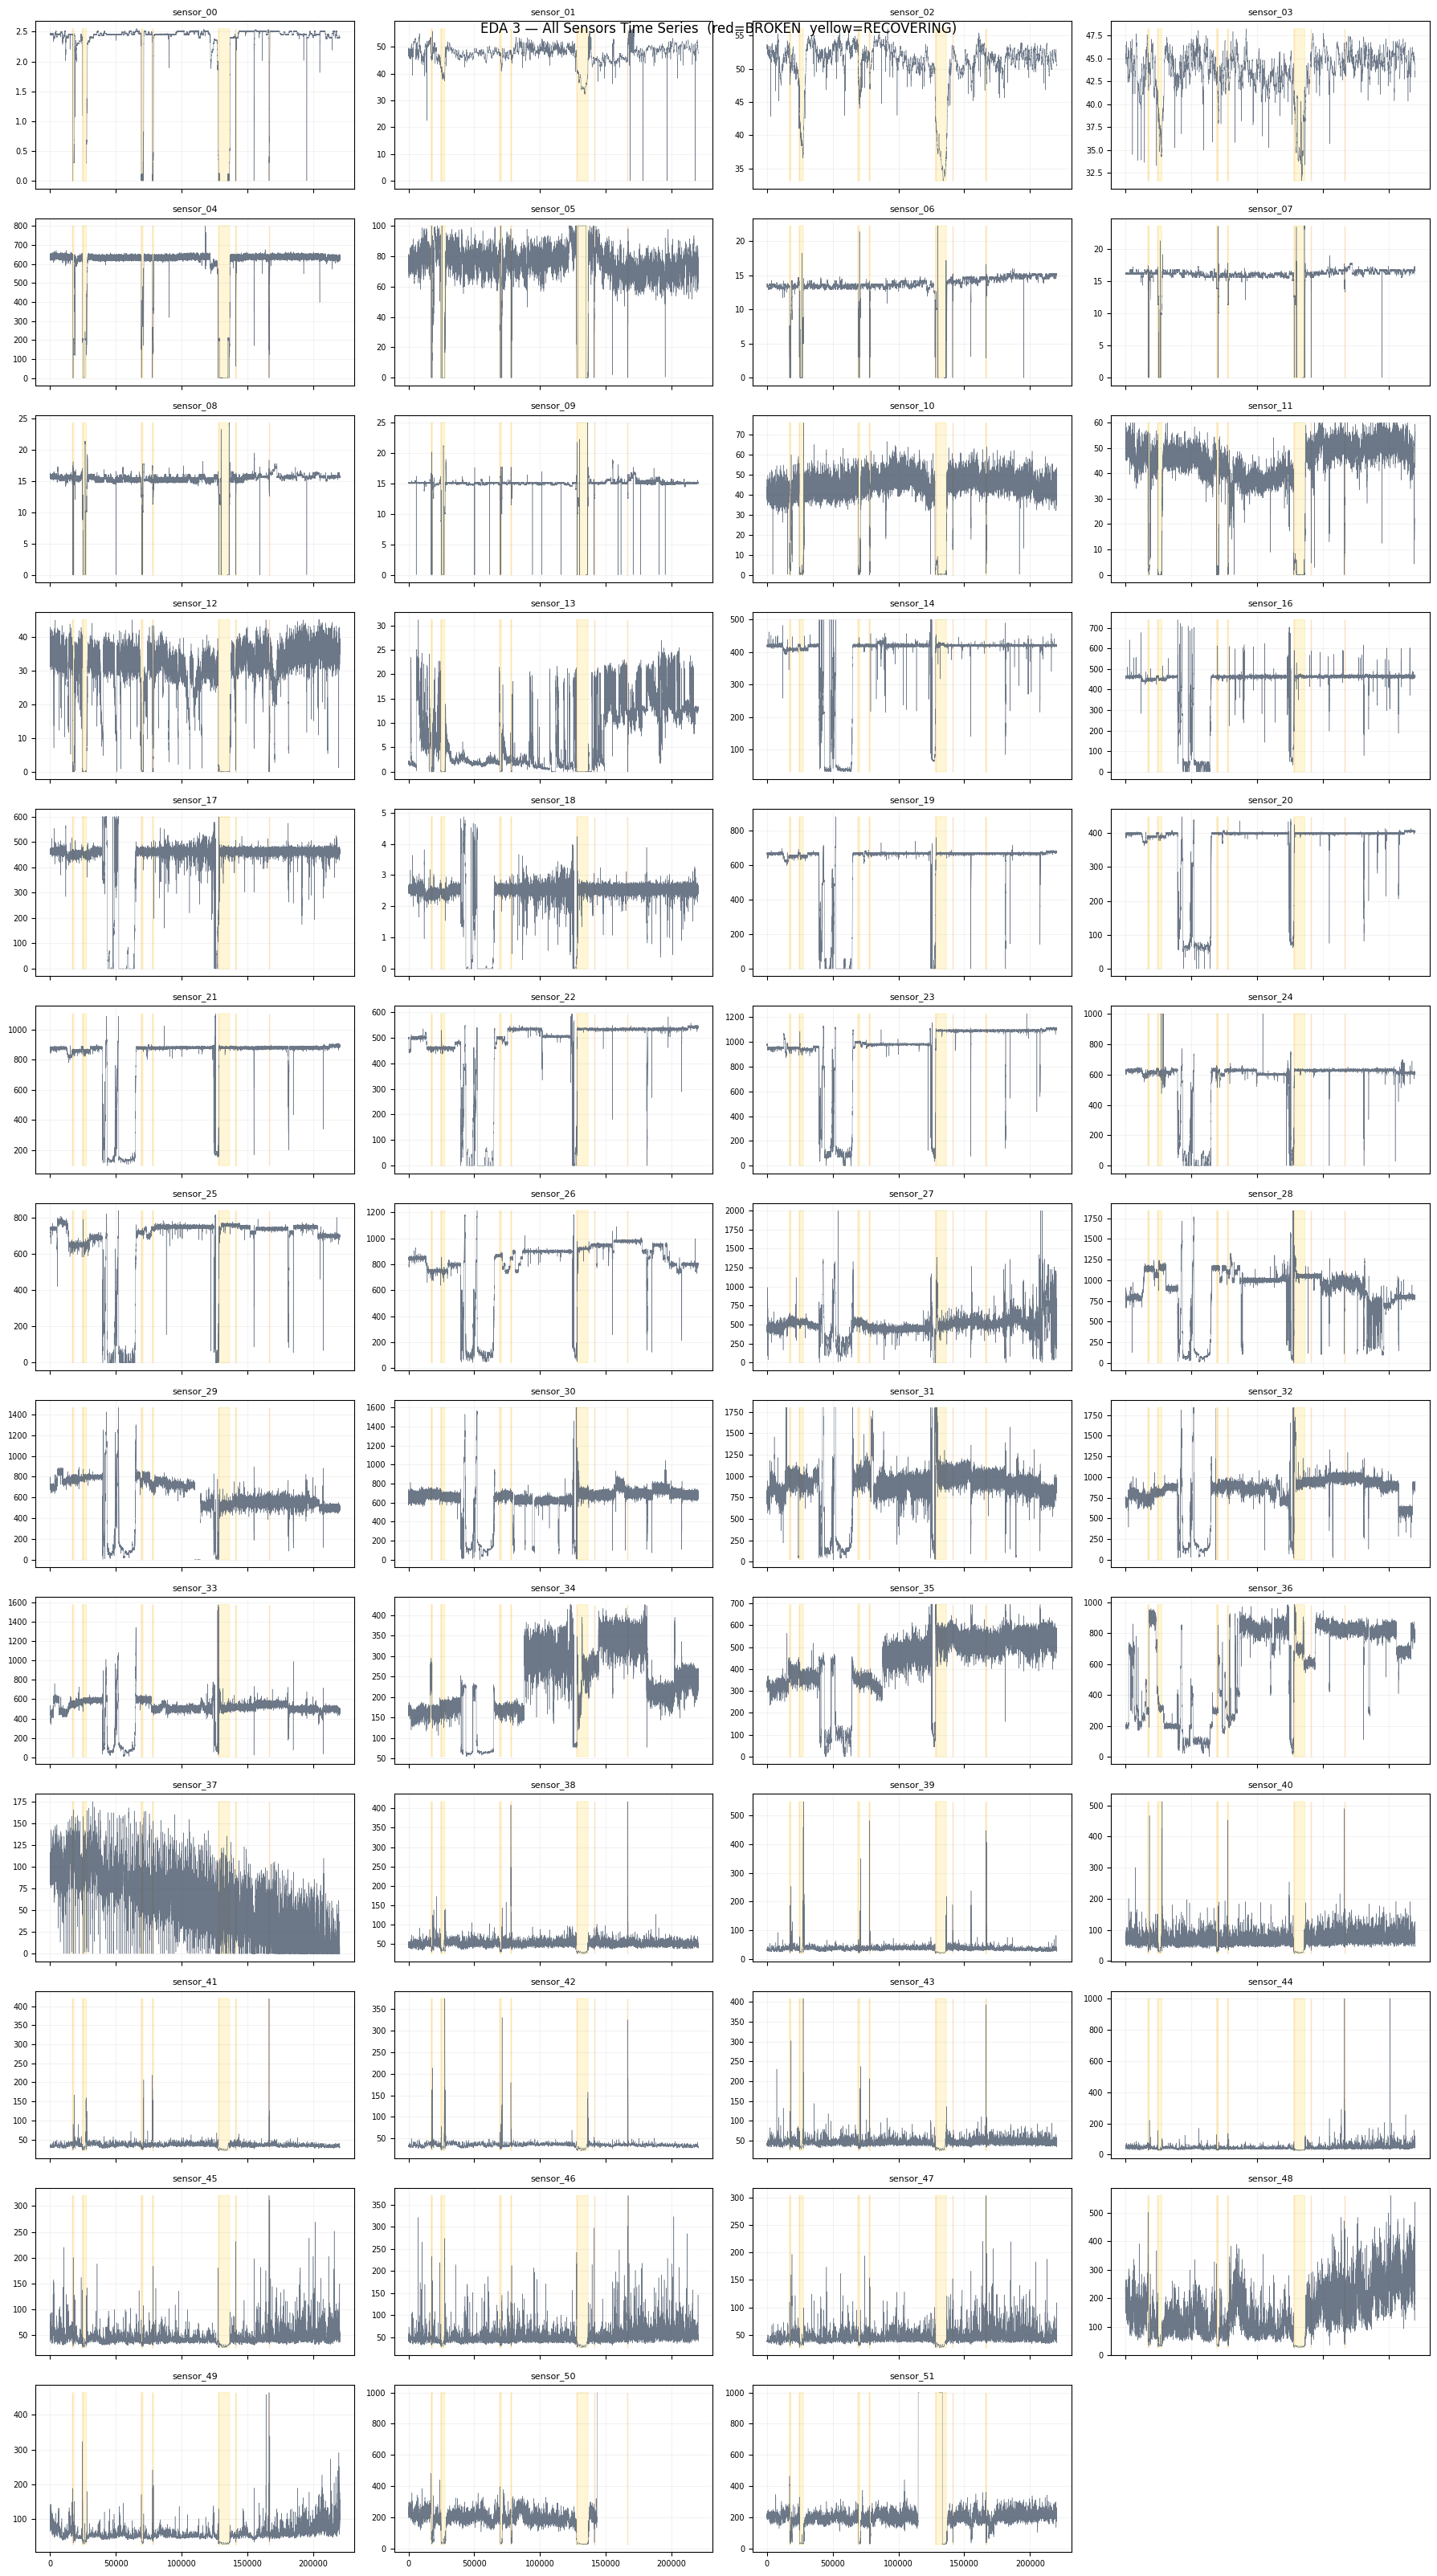

In [5]:
df_vis = df_raw[valid_sensors + ['machine_status']].copy()

n_col_plot = 4
n_row_plot = (len(valid_sensors) + n_col_plot - 1) // n_col_plot
fig, axes = plt.subplots(n_row_plot, n_col_plot,
                          figsize=(18, n_row_plot * 2.5), sharex=True)
axes = axes.flatten()

for idx, col in enumerate(valid_sensors):
    ax = axes[idx]
    ax.plot(range(len(df_vis)), df_vis[col].values,
            linewidth=0.35, color='#475569', alpha=0.8)
    for status, color in [('BROKEN','#FCA5A5'), ('RECOVERING','#FDE68A')]:
        mask = (df_vis['machine_status'] == status).values
        ax.fill_between(range(len(df_vis)),
                        df_vis[col].min(), df_vis[col].max(),
                        where=mask, alpha=0.35, color=color)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15)

for idx in range(len(valid_sensors), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('EDA 3 — All Sensors Time Series  (red=BROKEN  yellow=RECOVERING)',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_all_sensors.png', dpi=110, bbox_inches='tight')
plt.show()

### 2-3. KS-test: most discriminative sensors

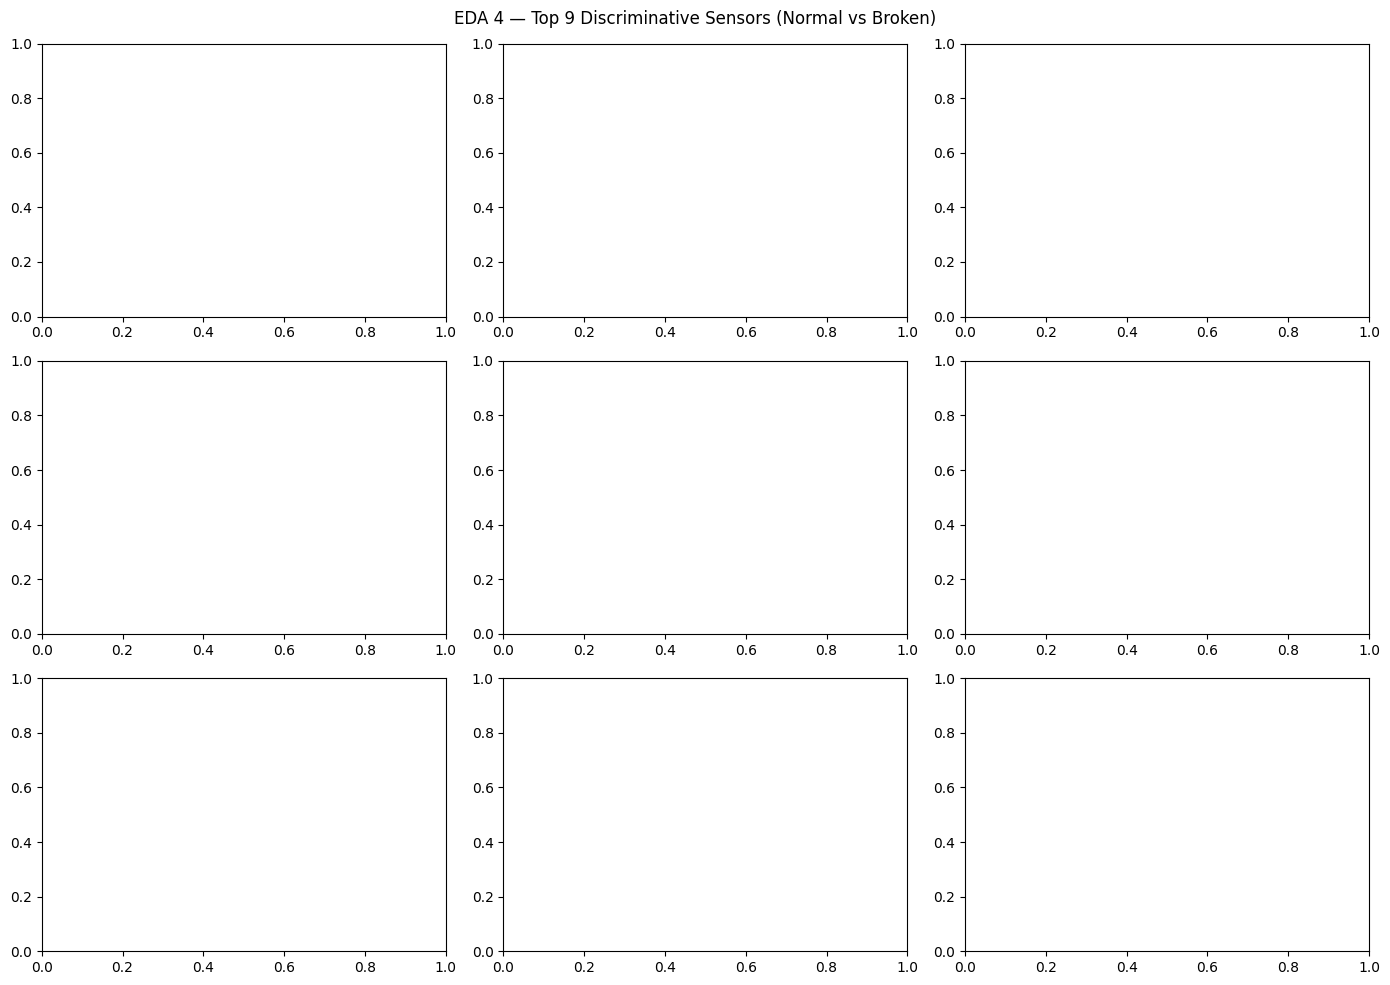

In [6]:
normal_df = df_vis[df_vis['machine_status']=='NORMAL'][valid_sensors]
broken_df = df_vis[df_vis['machine_status']=='BROKEN'][valid_sensors]

ks_scores = {}
for col in valid_sensors:
    a = normal_df[col].dropna()
    b = broken_df[col].dropna()
    if len(a) > 10 and len(b) > 10:
        stat, _ = stats.ks_2samp(a, b)
        ks_scores[col] = stat

top9 = sorted(ks_scores, key=ks_scores.get, reverse=True)[:9]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for idx, col in enumerate(top9):
    ax = axes[idx]
    ax.hist(normal_df[col].dropna(), bins=50, alpha=0.55,
            color='#93C5FD', label='Normal', density=True)
    ax.hist(broken_df[col].dropna(), bins=50, alpha=0.55,
            color='#FCA5A5', label='Broken', density=True)
    ax.set_title(f'{col}  KS={ks_scores[col]:.3f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
fig.suptitle('EDA 4 — Top 9 Discriminative Sensors (Normal vs Broken)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_ks_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2-4. ADF Stationarity test

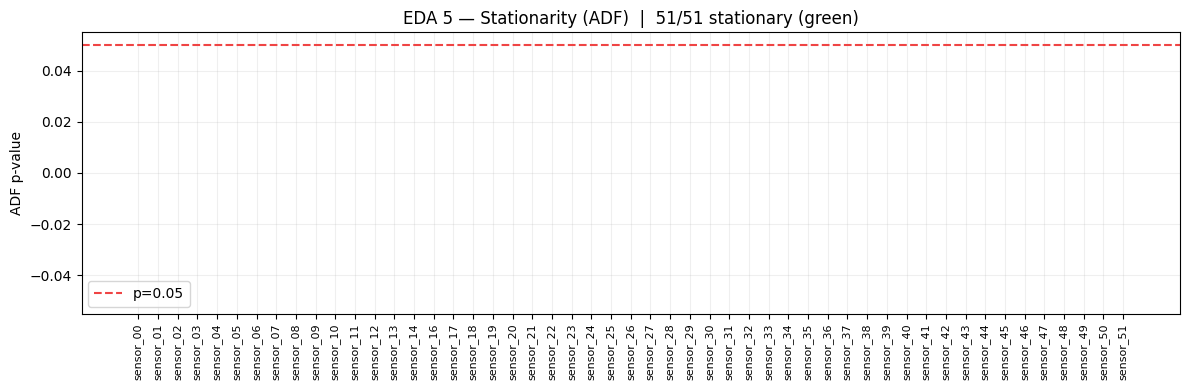

Non-stationary sensors: []


In [7]:
sample_adf = df_vis[valid_sensors].dropna().sample(
    min(5000, len(df_vis)), random_state=SEED)

adf_res = {}
for col in valid_sensors:
    s = sample_adf[col].dropna()
    if len(s) < 20:
        continue
    try:
        result = adfuller(s, autolag='AIC')
        adf_res[col] = {'p': result[1], 'stationary': result[1] < 0.05}
    except Exception:
        pass

adf_df = pd.DataFrame(adf_res).T
n_s = adf_df['stationary'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(adf_df.index, adf_df['p'],
       color=['#6EE7B7' if s else '#FCA5A5' for s in adf_df['stationary']],
       width=0.7)
ax.axhline(0.05, color='#EF4444', linestyle='--', lw=1.5, label='p=0.05')
ax.set_ylabel('ADF p-value')
ax.set_title(f'EDA 5 — Stationarity (ADF)  |  {n_s}/{len(adf_df)} stationary (green)')
ax.legend()
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_adf.png', dpi=150, bbox_inches='tight')
plt.show()

non_stationary = adf_df[adf_df['stationary'] == False].index.tolist()
print(f'Non-stationary sensors: {non_stationary}')

### 2-5. Pearson Correlation Matrix

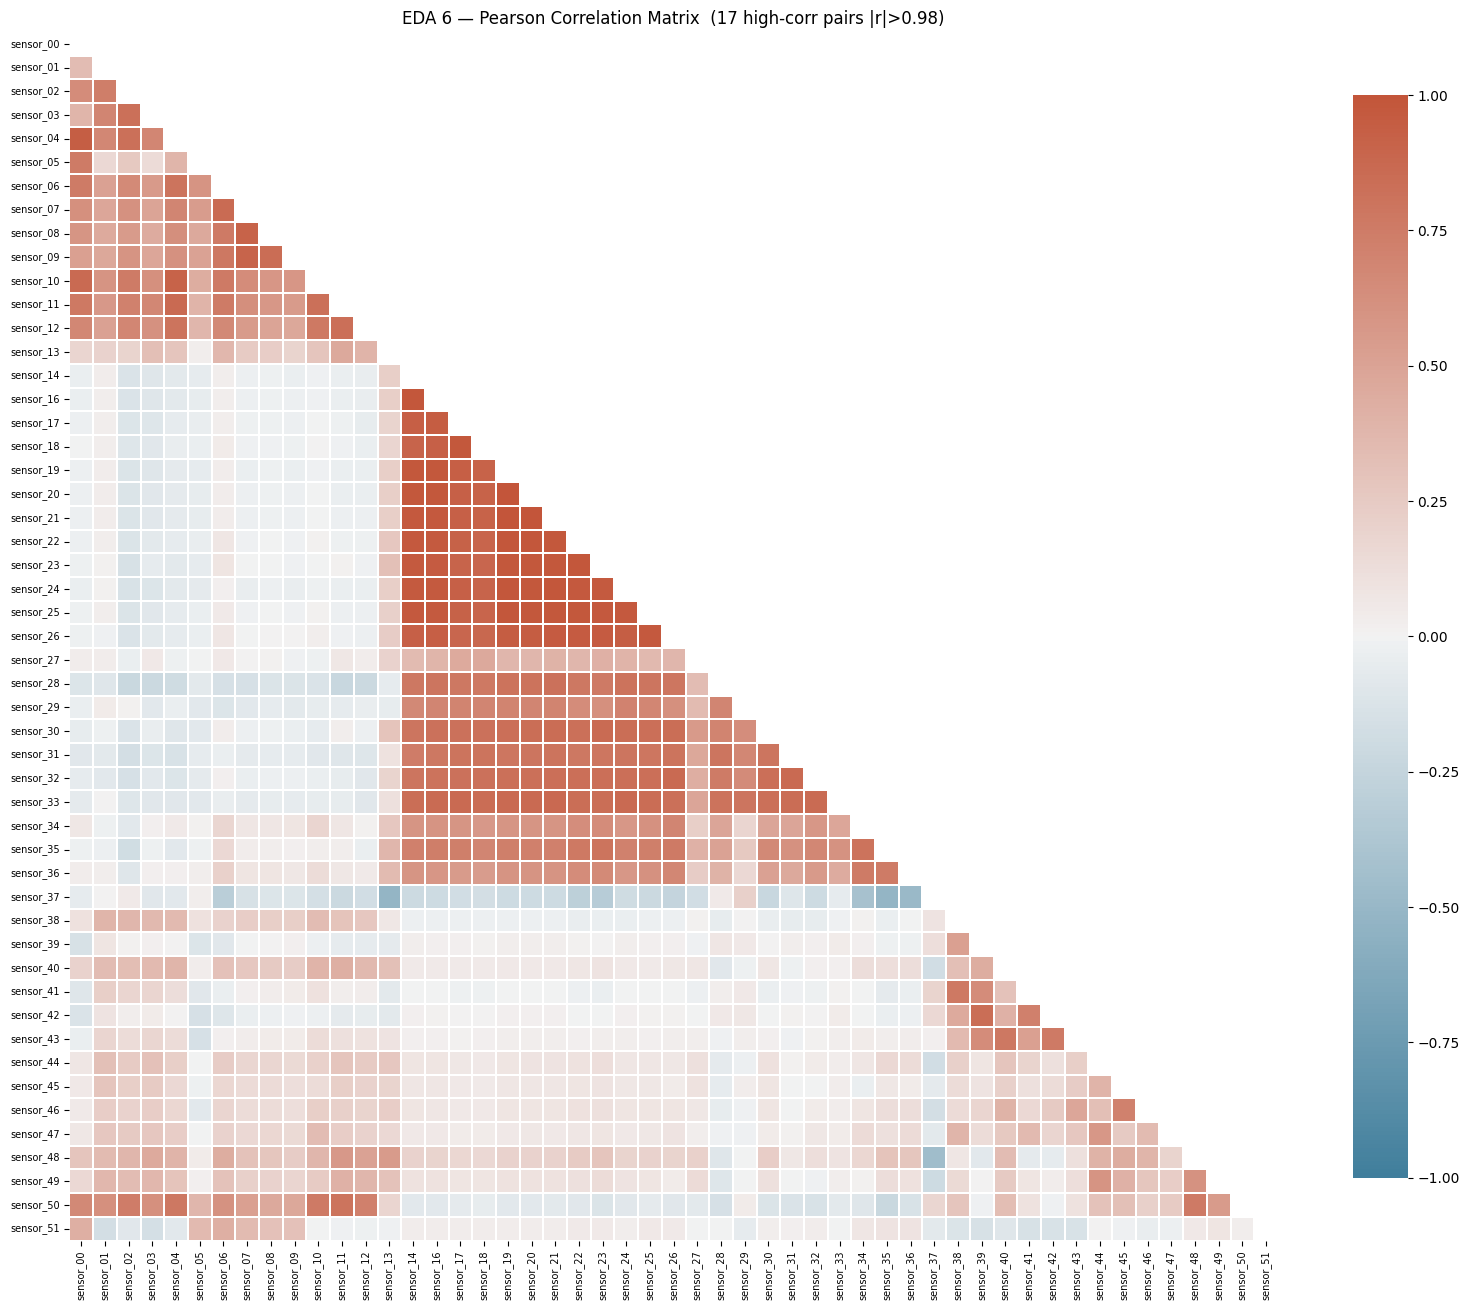

High-correlation pairs (|r|>0.98):
  sensor_19 <-> sensor_20 : r=0.9982
  sensor_20 <-> sensor_21 : r=0.9971
  sensor_19 <-> sensor_21 : r=0.996
  sensor_14 <-> sensor_16 : r=0.9904
  sensor_19 <-> sensor_22 : r=0.9882
  sensor_22 <-> sensor_23 : r=0.9869
  sensor_20 <-> sensor_22 : r=0.9865
  sensor_19 <-> sensor_24 : r=0.9856
  sensor_21 <-> sensor_24 : r=0.9849
  sensor_19 <-> sensor_25 : r=0.9848


In [8]:
corr_matrix = df_vis[valid_sensors].corr(method='pearson')

# 고상관 쌍 탐지
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i,j]
        if abs(v) > CORR_THRESH:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(v,4)))

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask,
            cmap=sns.diverging_palette(230,20,as_cmap=True),
            vmax=1, vmin=-1, center=0, square=True,
            linewidths=0.3, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title(f'EDA 6 — Pearson Correlation Matrix  ({len(high_corr_pairs)} high-corr pairs |r|>{CORR_THRESH})',
             fontsize=12)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'High-correlation pairs (|r|>{CORR_THRESH}):')
for a,b,v in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f'  {a} <-> {b} : r={v}')

---
## Section 3. Feature Selection — VIF Multicollinearity Removal

`VIF (Variance Inflation Factor)` 해석:
- VIF = 1: 완전 독립
- VIF 1~5: 허용 수준
- VIF 5~10: 주의
- **VIF > 10: 제거** — 해당 피처가 다른 피처들의 선형결합으로 거의 설명됨

알고리즘: 가장 높은 VIF 피처부터 하나씩 제거 후 재계산 반복 (Backward Elimination)

In [9]:
def compute_vif(df_feat):
    X = df_feat.dropna().astype(float)
    return pd.DataFrame({
        'feature': X.columns,
        'VIF':     [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)


def iterative_vif_drop(df_feat, threshold, verbose=True):
    remaining = list(df_feat.columns)
    log = []
    step = 0
    while True:
        step += 1
        vif = compute_vif(df_feat[remaining])
        top_vif   = vif.iloc[0]['VIF']
        top_feat  = vif.iloc[0]['feature']
        if top_vif <= threshold:
            if verbose: print(f'  [step {step}] Done — all VIF <= {threshold}')
            break
        if verbose: print(f'  [step {step}] Drop {top_feat:<15s}  VIF={top_vif:.2f}')
        log.append({'feature': top_feat, 'vif': round(top_vif,2), 'step': step})
        remaining.remove(top_feat)
    return remaining, pd.DataFrame(log)


# VIF 계산용 샘플 (속도 최적화)
vif_sample = df_vis[valid_sensors].dropna().sample(
    min(8000, len(df_vis)), random_state=SEED)

vif_before = compute_vif(vif_sample)
print('=== VIF Before Elimination (top 15) ===')
print(vif_before.head(15).to_string(index=False))

=== VIF Before Elimination (top 15) ===
  feature         VIF
sensor_20 7355.488165
sensor_21 5149.107728
sensor_19 4844.920093
sensor_08 1979.550499
sensor_02 1837.463999
sensor_03 1619.169801
sensor_07 1308.595717
sensor_23 1203.416779
sensor_14 1070.459667
sensor_09  920.978077
sensor_25  919.915516
sensor_01  873.760475
sensor_22  866.496716
sensor_16  825.981352
sensor_17  674.914081



=== Iterative VIF Elimination ===
  [step 1] Drop sensor_20        VIF=7355.49
  [step 2] Drop sensor_21        VIF=3477.94
  [step 3] Drop sensor_08        VIF=1979.53
  [step 4] Drop sensor_02        VIF=1792.04
  [step 5] Drop sensor_19        VIF=1348.37
  [step 6] Drop sensor_23        VIF=899.21
  [step 7] Drop sensor_25        VIF=883.86
  [step 8] Drop sensor_14        VIF=835.38
  [step 9] Drop sensor_01        VIF=825.79
  [step 10] Drop sensor_07        VIF=792.22
  [step 11] Drop sensor_17        VIF=534.05
  [step 12] Drop sensor_00        VIF=504.55
  [step 13] Drop sensor_22        VIF=428.91
  [step 14] Drop sensor_04        VIF=372.66
  [step 15] Drop sensor_06        VIF=337.47
  [step 16] Drop sensor_03        VIF=204.90
  [step 17] Drop sensor_26        VIF=203.05
  [step 18] Drop sensor_16        VIF=167.10
  [step 19] Drop sensor_43        VIF=136.57
  [step 20] Drop sensor_32        VIF=131.83
  [step 21] Drop sensor_41        VIF=117.59
  [step 22] Drop sensor_

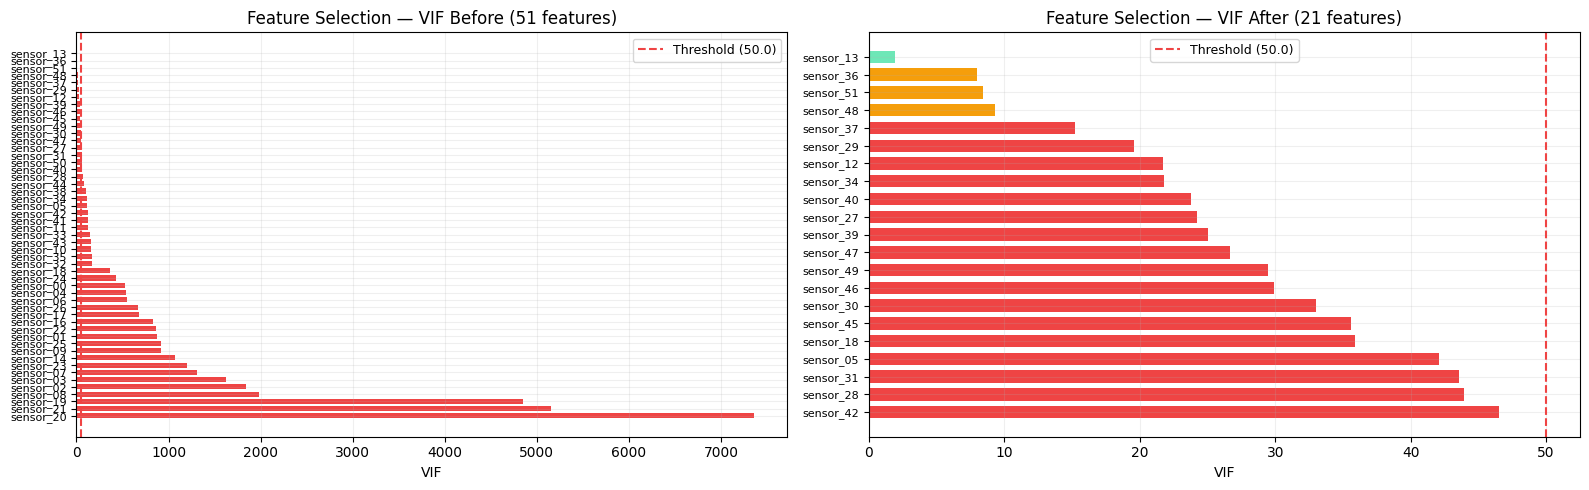

In [10]:
print('\n=== Iterative VIF Elimination ===')
selected_by_vif, vif_log = iterative_vif_drop(vif_sample, VIF_THRESH)

# 제로 분산 제거
zero_var = [c for c in selected_by_vif if df_vis[c].std() < 1e-6]
FINAL_FEATURES = [c for c in selected_by_vif if c not in zero_var]
N_FEATURES = len(FINAL_FEATURES)

vif_after = compute_vif(vif_sample[FINAL_FEATURES])

print(f'\n  Original   : {len(valid_sensors)} sensors')
print(f'  Dropped (VIF)    : {[c for c in valid_sensors if c not in selected_by_vif]}')
print(f'  Dropped (zero-var): {zero_var}')
print(f'  FINAL : {N_FEATURES} features')
print(f'\nFinal features: {FINAL_FEATURES}')

# VIF 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_i, (vdf, title_s) in enumerate([
    (vif_before, f'Before ({len(valid_sensors)} features)'),
    (vif_after,  f'After ({N_FEATURES} features)')]):
    ax = axes[ax_i]
    c = ['#EF4444' if v>10 else '#F59E0B' if v>5 else '#6EE7B7' for v in vdf['VIF']]
    ax.barh(vdf['feature'], vdf['VIF'], color=c, height=0.7)
    ax.axvline(VIF_THRESH, color='#EF4444', linestyle='--', lw=1.5,
               label=f'Threshold ({VIF_THRESH})')
    ax.set_xlabel('VIF')
    ax.set_title(f'Feature Selection — VIF {title_s}')
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_vif.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4. Preprocessing — Normalization + Sliding Window + Split

In [11]:
df_proc = df_raw[FINAL_FEATURES + ['machine_status']].copy()
df_proc = df_proc.reset_index(drop=True)

label_map = {'NORMAL': 0, 'BROKEN': 1, 'RECOVERING': 1}
df_proc['label'] = df_proc['machine_status'].map(label_map).fillna(0).astype(int)

# --- 시간 순서 기준 행 단위 train / val / test (랜덤 stratify 없음) ---
# 뒤 20~30%만 자르면 이 데이터에서 test에 이상 라벨이 없을 수 있어,
# train 55% / val 15% / test 30% 로 분할해 test에 RECOVERING 구간이 포함되도록 함.
n = len(df_proc)
SPLIT_TRAIN_FRAC, SPLIT_VAL_FRAC = 0.55, 0.15
i_tr = int(n * SPLIT_TRAIN_FRAC)
i_val = int(n * (SPLIT_TRAIN_FRAC + SPLIT_VAL_FRAC))

train_df = df_proc.iloc[:i_tr].copy()
val_df = df_proc.iloc[i_tr:i_val].copy()
test_df = df_proc.iloc[i_val:].copy()

def _impute_feat(df_part):
    df_part = df_part.copy()
    # 실시간/스트리밍: 미래 시점 참조 금지 → bfill 제거 (과거 ffill + 잔여는 0)
    df_part[FINAL_FEATURES] = df_part[FINAL_FEATURES].ffill().fillna(0.0)
    return df_part

train_df = _impute_feat(train_df)
val_df = _impute_feat(val_df)
test_df = _impute_feat(test_df)

print(f'[Split] n={n} | train {len(train_df)} | val {len(val_df)} | test {len(test_df)}')
print(f'[Split] anomaly %  train {train_df["label"].mean()*100:.2f}% | val {val_df["label"].mean()*100:.2f}% | test {test_df["label"].mean()*100:.2f}%')

normal_mask_tr = train_df['label'] == 0
if SCALER_TYPE == 'minmax':
    scaler = MinMaxScaler()
else:
    scaler = StandardScaler()

scaler.fit(train_df.loc[normal_mask_tr, FINAL_FEATURES])
pickle.dump(scaler, open(f'{MODEL_DIR}/scaler.pkl', 'wb'))
pickle.dump(FINAL_FEATURES, open(f'{MODEL_DIR}/final_features.pkl', 'wb'))

train_scaled = scaler.transform(train_df[FINAL_FEATURES]).astype(np.float32)
val_scaled = scaler.transform(val_df[FINAL_FEATURES]).astype(np.float32)
test_scaled = scaler.transform(test_df[FINAL_FEATURES]).astype(np.float32)

labels_train = train_df['label'].values
labels_val = val_df['label'].values
labels_test = test_df['label'].values

_all = np.vstack([train_scaled, val_scaled, test_scaled])
print(f'Scaler        : {SCALER_TYPE}')
print(f'Scaled range  : [{_all.min():.3f}, {_all.max():.3f}]')
print(f'Train / val / test shapes: {train_scaled.shape}, {val_scaled.shape}, {test_scaled.shape}')


Remaining nulls: 0
Scaler        : minmax
Scaled range  : [-0.015, 1.434]
Data shape    : (220320, 21)


X_train (normal) : torch.Size([16435, 50, 21])  — Autoencoder 학습용
X_test  (all)    : torch.Size([4406, 50, 21])
y_test anomaly   : 6.72% (이제 0%가 아닐 겁니다)


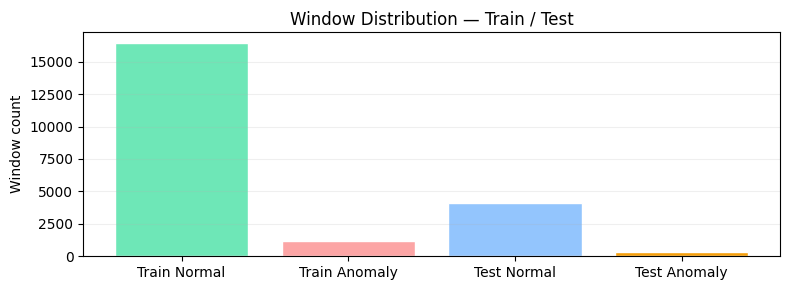

In [12]:
def make_windows(data, labels, win, step):
    """
    Sliding window 생성.
    window 내 이상 레이블이 하나라도 있으면 해당 window = 이상(1)
    Returns: X (N, win, feat), y (N,)
    """
    X, y = [], []
    for s in range(0, len(data) - win, step):
        X.append(data[s:s+win])
        y.append(int(labels[s:s+win].max()))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X_train_all, y_train_all = make_windows(train_scaled, labels_train, WINDOW_SIZE, STEP_SIZE)
X_val_all, y_val_all = make_windows(val_scaled, labels_val, WINDOW_SIZE, STEP_SIZE)
X_test, y_test = make_windows(test_scaled, labels_test, WINDOW_SIZE, STEP_SIZE)

normal_idx = np.where(y_train_all == 0)[0]
X_train = X_train_all[normal_idx]

X_train_t = torch.FloatTensor(X_train).to(device)
X_val_t = torch.FloatTensor(X_val_all).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

train_loader_default = DataLoader(
    TensorDataset(X_train_t, X_train_t),
    batch_size=DEFAULT_BATCH, shuffle=True,
    pin_memory=False, num_workers=0
)

print(f'X_train (normal) : {X_train_t.shape}  — Autoencoder 학습용')
print(f'X_val (all)      : {X_val_t.shape}')
print(f'X_test (all)     : {X_test_t.shape}')
print(f'y_val anomaly    : {y_val_all.mean()*100:.2f}%  |  y_test anomaly: {y_test.mean()*100:.2f}%')

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(['Train N', 'Train A', 'Val N', 'Val A', 'Test N', 'Test A'],
       [int((y_train_all == 0).sum()), int((y_train_all == 1).sum()),
        int((y_val_all == 0).sum()), int((y_val_all == 1).sum()),
        int((y_test == 0).sum()), int((y_test == 1).sum())],
       color=['#6EE7B7', '#FCA5A5', '#93C5FD', '#F59E0B', '#A7F3D0', '#FB923C'],
       edgecolor='white')
ax.set_title('Window Distribution — Train / Val / Test (temporal split)')
ax.set_ylabel('Window count')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_window_dist.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 5. Model Definitions (5종)

In [13]:
# ── Model A: LSTM Autoencoder ──────────────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=64, latent=32, layers=2, dropout=0.1, **kw):
        super().__init__()
        self.model_name = 'LSTM-AE'
        drop = dropout if layers > 1 else 0
        self.enc   = nn.LSTM(n_feat, hidden, layers, batch_first=True, dropout=drop)
        self.fc_e  = nn.Linear(hidden, latent)
        self.fc_d  = nn.Linear(latent, hidden)
        self.dec   = nn.LSTM(hidden, hidden, layers, batch_first=True, dropout=drop)
        self.out   = nn.Linear(hidden, n_feat)

    def forward(self, x):
        _, (h, _) = self.enc(x)
        z   = self.fc_e(h[-1])
        di  = self.fc_d(z).unsqueeze(1).repeat(1, x.size(1), 1)
        dec, _ = self.dec(di)
        return self.out(dec)


# ── Model B: CNN-1D Autoencoder ───────────────────────────────────
class CNN1DAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=64, latent=32, dropout=0.1, **kw):
        super().__init__()
        self.model_name = 'CNN1D-AE'
        self.enc = nn.Sequential(
            nn.Conv1d(n_feat, hidden, 7, padding=3), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden*2, 5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc_e = nn.Linear(hidden*2, latent)
        self.fc_d = nn.Linear(latent, hidden*2)
        self.dec = nn.Sequential(
            nn.ConvTranspose1d(hidden*2, hidden, 5, padding=2), nn.ReLU(), nn.Dropout(dropout),
            nn.ConvTranspose1d(hidden, n_feat, 7, padding=3)
        )

    def forward(self, x):
        W = x.size(1)
        z  = self.fc_e(self.enc(x.permute(0,2,1)).squeeze(-1))
        di = self.fc_d(z).unsqueeze(-1).repeat(1,1,W)
        return self.dec(di).permute(0,2,1)


# ── Model C: Transformer Autoencoder ─────────────────────────────
class TransformerAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=64, latent=32, nhead=4, layers=2, dropout=0.1, **kw):
        super().__init__()
        self.model_name = 'Transformer-AE'
        # nhead must divide hidden
        nhead = max(h for h in [1,2,4,8] if hidden % h == 0 and h <= nhead)
        self.proj = nn.Linear(n_feat, hidden)
        enc_l = nn.TransformerEncoderLayer(hidden, nhead, hidden*4, dropout, batch_first=True)
        self.tenc = nn.TransformerEncoder(enc_l, layers)
        self.fc_e = nn.Linear(hidden, latent)
        self.fc_d = nn.Linear(latent, hidden)
        dec_l = nn.TransformerDecoderLayer(hidden, nhead, hidden*4, dropout, batch_first=True)
        self.tdec = nn.TransformerDecoder(dec_l, layers)
        self.out  = nn.Linear(hidden, n_feat)

    def forward(self, x):
        p = self.proj(x)
        m = self.tenc(p)
        z = self.fc_e(m.mean(1))
        d = self.fc_d(z).unsqueeze(1).repeat(1, x.size(1), 1)
        return self.out(self.tdec(d, m))


print('Models A (LSTM-AE), B (CNN1D-AE), C (Transformer-AE) defined.')
print('Classical: D (Isolation Forest), E (One-Class SVM) — trained in Section 6.')

Models A (LSTM-AE), B (CNN1D-AE), C (Transformer-AE) defined.
Classical: D (Isolation Forest), E (One-Class SVM) — trained in Section 6.


---
## Section 6. Train All Models → Auto-Select Best

**흐름**: 5개 모델 학습 → 성능 비교 → `BEST_MODEL_NAME` 자동 설정 → Section 7에서 해당 모델만 Optuna 튜닝

In [14]:
# ── 공통 유틸리티 ──────────────────────────────────────────────────
def train_autoencoder(model, loader, epochs, patience=10, verbose=True):
    """EarlyStopping + AMP 포함 학습 루프"""
    model.train()
    criterion  = nn.MSELoss()
    optimizer  = torch.optim.AdamW(model.parameters(), lr=DEFAULT_LR, weight_decay=1e-5)
    scaler_amp = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
    best_loss, no_imp, history = float('inf'), 0, []

    for epoch in range(1, epochs + 1):
        ep_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                loss = criterion(model(xb), yb)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            ep_loss += loss.item()
        avg = ep_loss / len(loader)
        history.append(avg)
        if avg < best_loss: best_loss, no_imp = avg, 0
        else: no_imp += 1
        if no_imp >= patience:
            if verbose: print(f'    EarlyStop @ {epoch}  best={best_loss:.6f}')
            break
        if verbose and epoch % 10 == 0:
            print(f'    Epoch {epoch:3d}  loss={avg:.6f}')
    return history


def get_errors(model, X_tensor, batch=512):
    """배치 단위 재구성 오차 계산 (AMP 적용)"""
    model.eval()
    errs = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch):
            b = X_tensor[i:i + batch]
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                recon = model(b)
            errs.extend(((b - recon) ** 2).mean(dim=(1, 2)).cpu().numpy())
    return np.array(errs)


def evaluate(errors, y_true, pct=THRESHOLD_PCT):
    errors = np.nan_to_num(errors, nan=0.0, posinf=0.0, neginf=0.0)
    """임계값 설정 + 분류 지표 계산"""
    thr    = np.percentile(errors, pct)
    y_pred = (errors > thr).astype(int)
    return dict(
        threshold = thr,
        y_pred    = y_pred,
        errors    = errors,
        f1        = f1_score(y_true, y_pred, zero_division=0),
        precision = precision_score(y_true, y_pred, zero_division=0),
        recall    = recall_score(y_true, y_pred, zero_division=0),
        roc_auc   = roc_auc_score(y_true, errors),
        pr_auc    = average_precision_score(y_true, errors),
    )


print('Utilities ready.')


Utilities ready.


In [15]:
results     = {}      # 모든 결과 저장
model_objs  = {}      # 딥러닝 모델 객체 저장 (Optuna 후 재사용)
DEEP_MODEL_CLASSES = {
    'LSTM-AE':        LSTMAutoencoder,
    'CNN1D-AE':       CNN1DAutoencoder,
    'Transformer-AE': TransformerAutoencoder,
}
plot_colors = ['#6366F1','#10B981','#F59E0B','#EF4444','#8B5CF6']

# ── 딥러닝 3종 학습 ────────────────────────────────────────────────
for i, (mname, ModelCls) in enumerate(DEEP_MODEL_CLASSES.items()):
    print(f'\n[{i+1}/5] Training {mname} ...')
    t0    = time.time()
    model = ModelCls(N_FEATURES, hidden=DEFAULT_HIDDEN, latent=DEFAULT_LATENT,
                     layers=DEFAULT_LAYERS, dropout=DEFAULT_DROPOUT, nhead=4).to(device)
    hist  = train_autoencoder(model, train_loader_default, DEFAULT_EPOCHS, patience=10)
    errs  = get_errors(model, X_test_t)
    met   = evaluate(errs, y_test)
    met.update({'history': hist, 'train_time': round(time.time()-t0,1)})
    results[mname]    = met
    model_objs[mname] = model
    torch.save(model.state_dict(), f'{MODEL_DIR}/{mname}_default.pt')
    print(f'    F1={met["f1"]:.4f}  ROC-AUC={met["roc_auc"]:.4f}  ({met["train_time"]}s)')

# ── 전통 ML 2종 ────────────────────────────────────────────────────
Xtr_flat = X_train_t.cpu().numpy().reshape(len(X_train_t), -1)
Xte_flat = X_test_t.cpu().numpy().reshape(len(X_test_t), -1)

print('\n[4/5] Training Isolation Forest ...')
t0 = time.time()
iforest = IsolationForest(n_estimators=200, contamination='auto', random_state=SEED, n_jobs=-1)
iforest.fit(Xtr_flat)
sc_if = -iforest.score_samples(Xte_flat)
met_if = evaluate(sc_if, y_test)
met_if['train_time'] = round(time.time()-t0,1)
results['IForest'] = met_if
print(f'    F1={met_if["f1"]:.4f}  ({met_if["train_time"]}s)')

print('\n[5/5] Training One-Class SVM ...')
t0 = time.time()
idx_s = np.random.choice(len(Xtr_flat), min(5000, len(Xtr_flat)), replace=False)
ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm.fit(Xtr_flat[idx_s])
sc_sv = -ocsvm.score_samples(Xte_flat)
met_sv = evaluate(sc_sv, y_test)
met_sv['train_time'] = round(time.time()-t0,1)
results['OCSVM'] = met_sv
print(f'    F1={met_sv["f1"]:.4f}  ({met_sv["train_time"]}s)')


[1/5] Training LSTM-AE ...
    Epoch  10  loss=0.002630
    Epoch  20  loss=0.001765
    Epoch  30  loss=0.001666
    Epoch  40  loss=0.001404
    Epoch  50  loss=0.001339
    Epoch  60  loss=0.001221
    Epoch  70  loss=0.001158
    Epoch  80  loss=0.001127
    Epoch  90  loss=0.001119
    Epoch 100  loss=0.001083
    F1=0.4526  ROC-AUC=0.8891  (189.9s)

[2/5] Training CNN1D-AE ...
    Epoch  10  loss=0.001704
    Epoch  20  loss=0.001427
    Epoch  30  loss=0.001334
    Epoch  40  loss=0.001278
    Epoch  50  loss=0.001258
    Epoch  60  loss=0.001233
    Epoch  70  loss=0.001204
    Epoch  80  loss=0.001192
    Epoch  90  loss=0.001155
    Epoch 100  loss=0.001151
    F1=0.1896  ROC-AUC=0.7868  (118.5s)

[3/5] Training Transformer-AE ...
    Epoch  10  loss=0.001028
    Epoch  20  loss=0.000956
    Epoch  30  loss=0.000942
    Epoch  40  loss=0.000927
    Epoch  50  loss=0.000924
    Epoch  60  loss=0.000921
    Epoch  70  loss=0.000917
    Epoch  80  loss=0.000916
    Epoch  90  l


=== Model Comparison ===
           LSTM-AE  CNN1D-AE  Transformer-AE  IForest   OCSVM
f1          0.4526    0.1896          0.0967   0.5532  0.7041
precision   0.5294    0.2217          0.1131   0.6471  0.8235
recall      0.3953    0.1655          0.0845   0.4831  0.6149
roc_auc     0.8891    0.7868          0.2908   0.9785  0.9857
pr_auc      0.4834    0.2057          0.0716   0.6191  0.7557


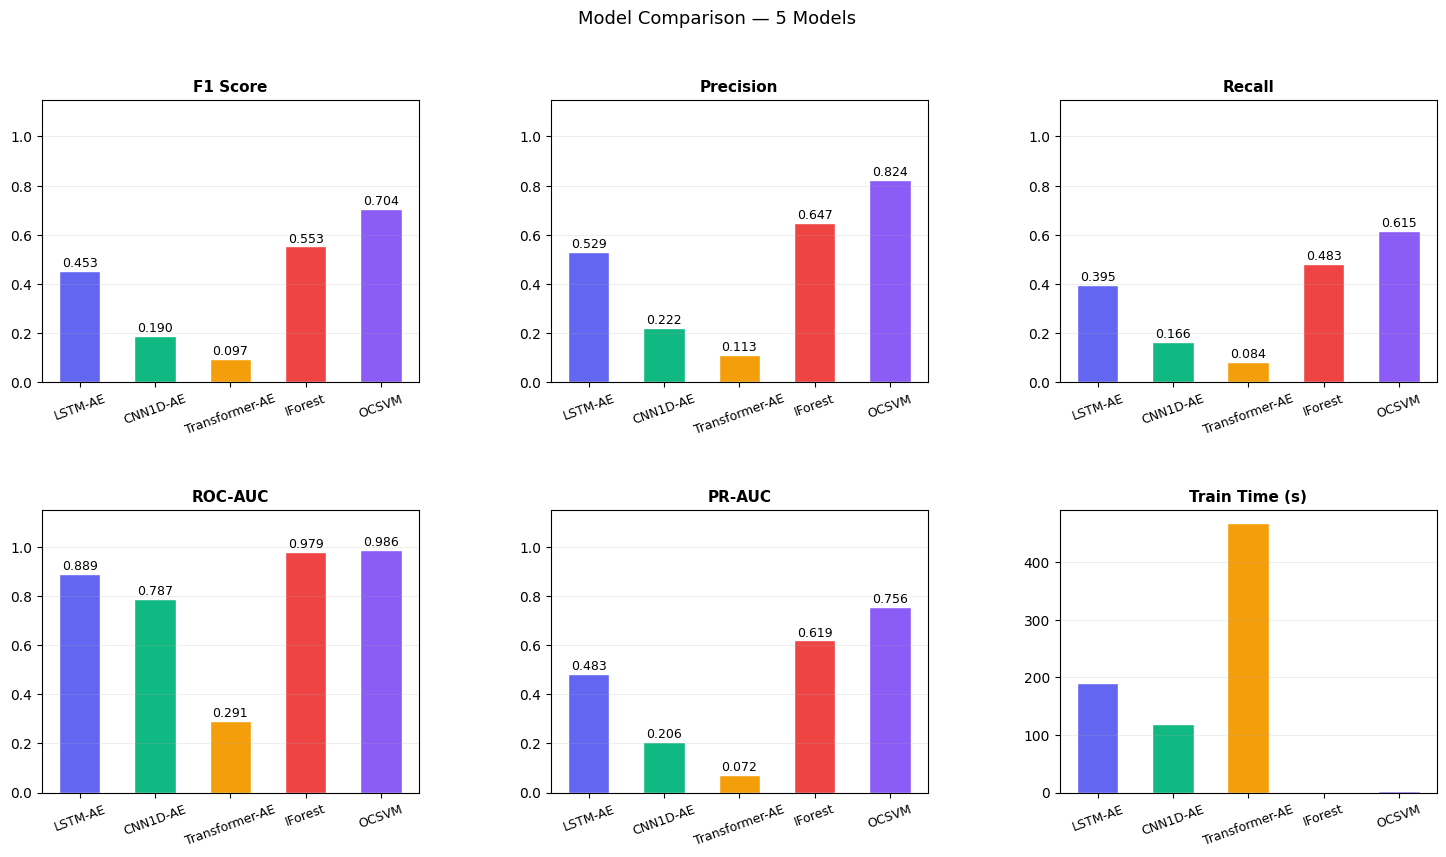

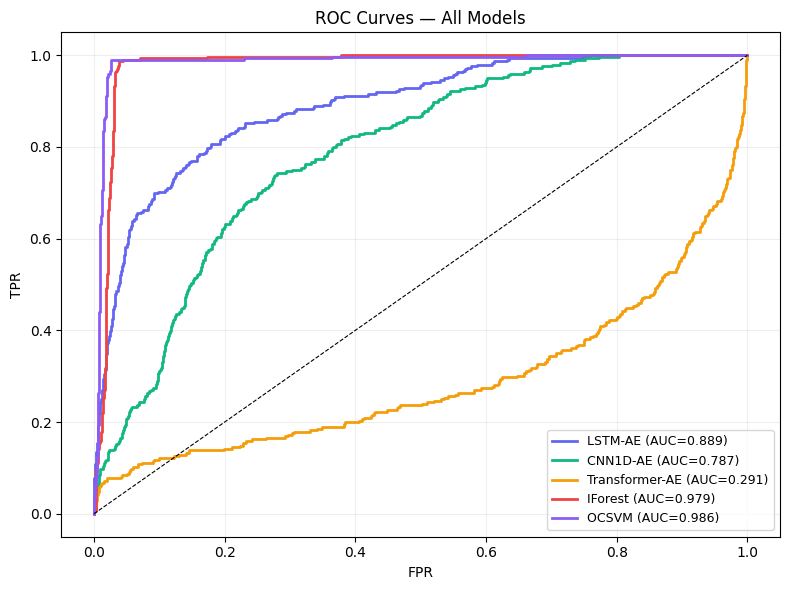

In [16]:
# ── 성능 비교 시각화 ───────────────────────────────────────────────
model_names  = list(results.keys())
metrics_keys = ['f1','precision','recall','roc_auc','pr_auc']
mtitles      = ['F1 Score','Precision','Recall','ROC-AUC','PR-AUC']

comp_df = pd.DataFrame(
    {k: {m: round(results[m][k],4) for m in model_names} for k in metrics_keys}
).T
print('\n=== Model Comparison ===')
print(comp_df.to_string())

fig = plt.figure(figsize=(18,9))
gs  = gridspec.GridSpec(2,3, figure=fig, hspace=0.45, wspace=0.35)

for mi,(key,title) in enumerate(zip(metrics_keys, mtitles)):
    ax = fig.add_subplot(gs[mi//3, mi%3])
    vals = [results[m][key] for m in model_names]
    bars = ax.bar(model_names, vals, color=plot_colors[:len(model_names)],
                  width=0.55, edgecolor='white')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0,1.15); ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20, labelsize=9); ax.grid(True, alpha=0.2, axis='y')

ax_t = fig.add_subplot(gs[1,2])
ax_t.bar(model_names, [results[m]['train_time'] for m in model_names],
         color=plot_colors[:len(model_names)], width=0.55, edgecolor='white')
ax_t.set_title('Train Time (s)', fontsize=11, fontweight='bold')
ax_t.tick_params(axis='x', rotation=20, labelsize=9); ax_t.grid(True, alpha=0.2, axis='y')

fig.suptitle('Model Comparison — 5 Models', fontsize=13)
plt.savefig(f'{OUTPUT_DIR}/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC 곡선
fig, ax = plt.subplots(figsize=(8,6))
for i,mname in enumerate(model_names):
    fpr,tpr,_ = roc_curve(y_test, results[mname]['errors'])
    ax.plot(fpr,tpr, color=plot_colors[i], lw=2,
            label=f'{mname} (AUC={results[mname]["roc_auc"]:.3f})')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — All Models'); ax.legend(fontsize=9); ax.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_roc.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ══════════════════════════════════════════════════════════════════
#  자동 모델 선정 (분기)
#  딥러닝 3종 중 PR_AUC 최고 모델 → Optuna 튜닝 대상
#  전통 ML은 비교 기준선 역할만
# ══════════════════════════════════════════════════════════════════
BEST_MODEL_NAME = max(
    DEEP_MODEL_CLASSES.keys(),
    key=lambda m: results[m]['pr_auc']
)
BEST_MODEL_CLS  = DEEP_MODEL_CLASSES[BEST_MODEL_NAME]

print('=' * 55)
print(f'  AUTO-SELECTED BEST MODEL: {BEST_MODEL_NAME}')
print(f'  Default F1   : {results[BEST_MODEL_NAME]["f1"]:.4f}')
print(f'  Default AUC  : {results[BEST_MODEL_NAME]["roc_auc"]:.4f}')
print(f'  → Section 7에서 이 모델만 Optuna 튜닝')
print('=' * 55)

  AUTO-SELECTED BEST MODEL: LSTM-AE
  Default F1   : 0.4526
  Default AUC  : 0.8891
  → Section 7에서 이 모델만 Optuna 튜닝


---
## Section 7. Optuna Auto-Tuning (선정 모델 자동 적용)

`BEST_MODEL_NAME`이 자동으로 설정된 상태에서 바로 실행됩니다.
탐색 공간: hidden/latent 크기, layer 수, dropout, lr, batch_size, optimizer, threshold_pct

In [18]:
# --- Window Cache (train/val/test 각각 동일 분할 기준) ---
print('Building window cache (upfront)...')
WINDOW_CACHE = {}
for _ws in [30, 50, 100, 150]:
    Xt, yt = make_windows(train_scaled, labels_train, _ws, STEP_SIZE)
    Xv, yv = make_windows(val_scaled, labels_val, _ws, STEP_SIZE)
    Xte, yte = make_windows(test_scaled, labels_test, _ws, STEP_SIZE)
    _ni = np.where(yt == 0)[0]
    WINDOW_CACHE[_ws] = {
        'X_train': torch.FloatTensor(Xt[_ni]),
        'X_val': torch.FloatTensor(Xv),
        'y_val': yv,
        'X_test': torch.FloatTensor(Xte),
        'y_test': yte,
    }
print(f'Cache ready: {list(WINDOW_CACHE.keys())}')

print(f'Optuna target: {BEST_MODEL_NAME}  |  n_trials={OPTUNA_TRIALS}')
best_trial_f1 = 0.0


def objective(trial):
    hidden = trial.suggest_categorical('hidden', [32, 64, 128, 256])
    latent = trial.suggest_categorical('latent', [8, 16, 32, 64])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.0, 0.4, step=0.05)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    batch = trial.suggest_categorical('batch', [32, 64, 128, 256])
    opt_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    thr_pct = trial.suggest_categorical('threshold_pct', [90, 93, 95, 97, 99])
    window_size = trial.suggest_categorical('window_size', [30, 50, 100, 150])

    cache = WINDOW_CACHE[window_size]
    X_tr_normal = cache['X_train'].to(device)
    X_va_t = cache['X_val'].to(device)
    y_va_arr = cache['y_val']

    loader = DataLoader(
        TensorDataset(X_tr_normal, X_tr_normal),
        batch_size=batch, shuffle=True,
        pin_memory=False, num_workers=0
    )

    model = BEST_MODEL_CLS(
        N_FEATURES, hidden=hidden, latent=latent,
        layers=n_layers, dropout=dropout, nhead=4
    ).to(device)

    opt_map = {'Adam': torch.optim.Adam,
               'AdamW': torch.optim.AdamW,
               'RMSprop': torch.optim.RMSprop}
    optimizer = opt_map[opt_name](model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)
    criterion = nn.MSELoss()
    scaler_amp = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    model.train()
    for epoch in range(30):
        ep_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                loss = criterion(model(xb), yb)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            ep_loss += loss.item()
        scheduler.step()
        trial.report(ep_loss / len(loader), epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    errs = get_errors(model, X_va_t)
    f1 = evaluate(errs, y_va_arr, thr_pct)['f1']

    global best_trial_f1
    if f1 > best_trial_f1:
        best_trial_f1 = f1
        torch.save(model.state_dict(), f'{MODEL_DIR}/{BEST_MODEL_NAME}_optuna_best.pt')
        print(f'  [Trial {trial.number}] New best Val F1={f1:.4f} → saved')

    return f1


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)
study.optimize(objective, n_trials=OPTUNA_TRIALS, catch=(ValueError,))

BEST_PARAMS = study.best_params
print(f'\nOptuna Best Val F1 : {study.best_value:.4f}')
print(f'Sec.6 baseline Test F1: {results[BEST_MODEL_NAME]["f1"]:.4f} (test split; Optuna objective는 Val F1)')
print(f'Best Params        : {BEST_PARAMS}')


Building window cache (upfront)...
Cache ready: [30, 50, 100, 150]
Optuna target: LSTM-AE  |  n_trials=500
  [Trial 0] New best F1=0.7736 → saved
  [Trial 10] New best F1=0.8264 → saved
  [Trial 13] New best F1=0.8298 → saved
  [Trial 118] New best F1=0.8391 → saved
  [Trial 122] New best F1=0.8425 → saved

Optuna Best F1  : 0.8425
Default F1      : 0.4526
Improvement     : +0.3898
Best Params     : {'hidden': 128, 'latent': 64, 'n_layers': 2, 'dropout': 0.15000000000000002, 'lr': 0.0035152573338537597, 'weight_decay': 0.0001052997851579664, 'batch': 256, 'optimizer': 'RMSprop', 'threshold_pct': 93, 'window_size': 30}


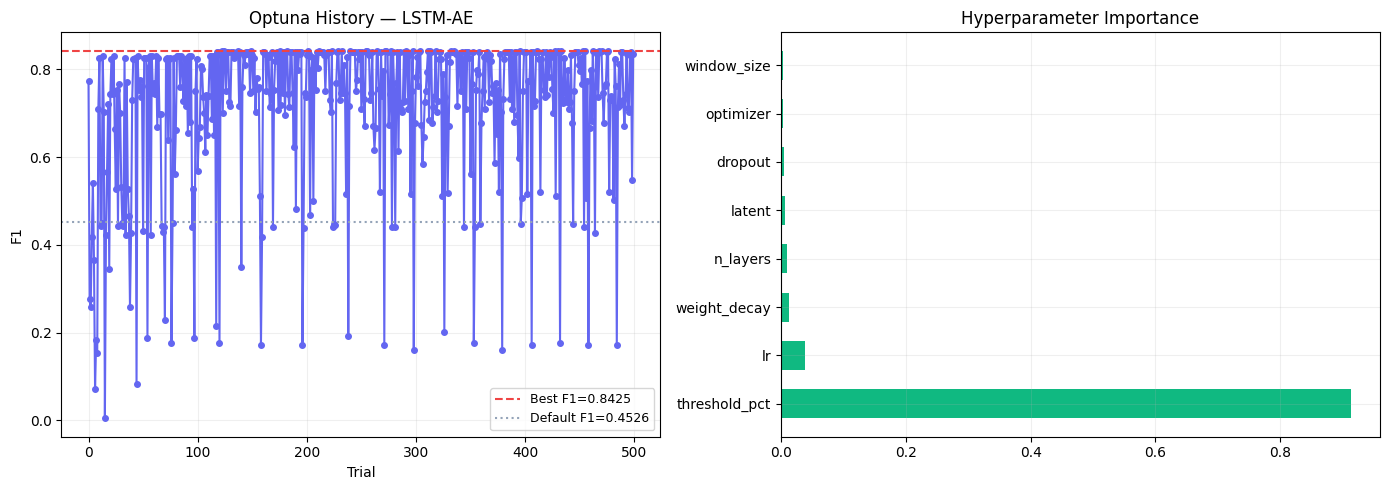

In [19]:
# Optuna 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 최적화 히스토리
trial_vals = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_vals, 'o-', color='#6366F1', markersize=4, lw=1.5)
axes[0].axhline(study.best_value, color='#EF4444', linestyle='--',
                label=f'Best F1={study.best_value:.4f}')
axes[0].axhline(results[BEST_MODEL_NAME]['f1'], color='#94A3B8',
                linestyle=':', label=f'Default F1={results[BEST_MODEL_NAME]["f1"]:.4f}')
axes[0].set_title(f'Optuna History — {BEST_MODEL_NAME}')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

# 파라미터 중요도
try:
    imp = optuna.importance.get_param_importances(study)
    ks_i = list(imp.keys())[:8]; vs_i = [imp[k] for k in ks_i]
    axes[1].barh(ks_i, vs_i, color='#10B981', height=0.6)
    axes[1].set_title('Hyperparameter Importance')
    axes[1].grid(True, alpha=0.2)
except Exception:
    axes[1].text(0.5, 0.5, 'Need more trials', ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_optuna.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8. Final Retrain with Best Params + Full Evaluation

In [20]:
p = BEST_PARAMS
print(f'Retraining {BEST_MODEL_NAME} with tuned params: {p}')

final_model = BEST_MODEL_CLS(
    N_FEATURES,
    hidden  = p['hidden'],
    latent  = p['latent'],
    layers  = p['n_layers'],
    dropout = p['dropout'],
    nhead   = 4
).to(device)

opt_map = {'Adam': torch.optim.Adam, 'AdamW': torch.optim.AdamW, 'RMSprop': torch.optim.RMSprop}
final_optimizer = opt_map[p['optimizer']](final_model.parameters(),
                                           lr=p['lr'], weight_decay=1e-5)
final_loader = DataLoader(TensorDataset(X_train_t, X_train_t),
                           batch_size=p['batch'], shuffle=True)

final_hist = train_autoencoder(final_model, final_loader, 50, patience=10, verbose=True)
final_errors  = get_errors(final_model, X_test_t)
final_metrics = evaluate(final_errors, y_test, p['threshold_pct'])

torch.save(final_model.state_dict(), f'{MODEL_DIR}/{BEST_MODEL_NAME}_tuned.pt')

print(f'\n=== Final Tuned Model: {BEST_MODEL_NAME} ===')
print(f'  F1        : {final_metrics["f1"]:.4f}  (default: {results[BEST_MODEL_NAME]["f1"]:.4f})')
print(f'  Precision : {final_metrics["precision"]:.4f}')
print(f'  Recall    : {final_metrics["recall"]:.4f}')
print(f'  ROC-AUC   : {final_metrics["roc_auc"]:.4f}')
print(f'  PR-AUC    : {final_metrics["pr_auc"]:.4f}')
print(f'  Threshold : {final_metrics["threshold"]:.6f}')

Retraining LSTM-AE with tuned params: {'hidden': 128, 'latent': 64, 'n_layers': 2, 'dropout': 0.15000000000000002, 'lr': 0.0035152573338537597, 'weight_decay': 0.0001052997851579664, 'batch': 256, 'optimizer': 'RMSprop', 'threshold_pct': 93, 'window_size': 30}
    Epoch  10  loss=0.004351
    Epoch  20  loss=0.002746
    Epoch  30  loss=0.002085
    Epoch  40  loss=0.001731
    Epoch  50  loss=0.001708

=== Final Tuned Model: LSTM-AE ===
  F1        : 0.5950  (default: 0.4526)
  Precision : 0.5825
  Recall    : 0.6081
  ROC-AUC   : 0.9452
  PR-AUC    : 0.5839
  Threshold : 0.005258


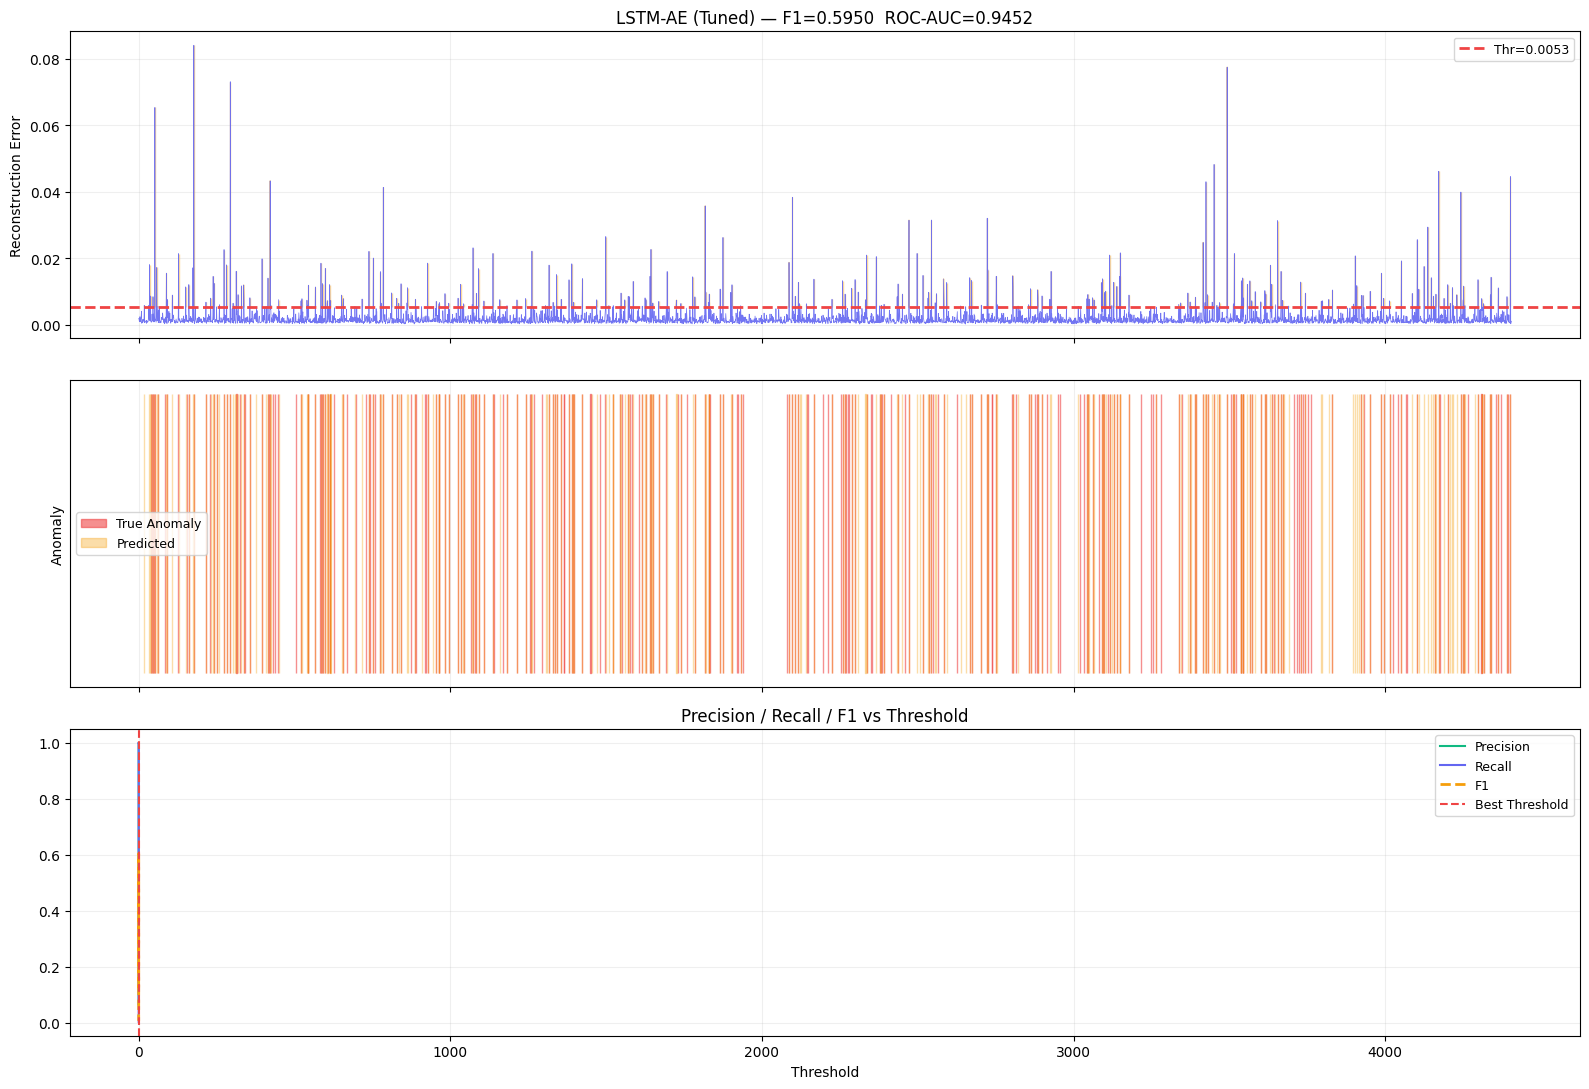

In [21]:
# 최종 결과 종합 시각화
fig, axes = plt.subplots(3, 1, figsize=(16,11), sharex=True)
idx  = np.arange(len(final_errors))
thr  = final_metrics['threshold']

axes[0].plot(idx, final_errors, color='#6366F1', lw=0.5, alpha=0.9)
axes[0].axhline(thr, color='#EF4444', lw=2, linestyle='--', label=f'Thr={thr:.4f}')
axes[0].fill_between(idx, final_errors, thr,
                     where=final_errors>thr, alpha=0.4, color='#F59E0B')
axes[0].set_ylabel('Reconstruction Error')
axes[0].set_title(f'{BEST_MODEL_NAME} (Tuned) — F1={final_metrics["f1"]:.4f}  ROC-AUC={final_metrics["roc_auc"]:.4f}',
                  fontsize=12)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

axes[1].fill_between(idx, 0, 1, where=y_test==1,
                     alpha=0.6, color='#EF4444', label='True Anomaly')
axes[1].fill_between(idx, 0, 1, where=final_metrics['y_pred']==1,
                     alpha=0.35, color='#F59E0B', label='Predicted')
axes[1].set_ylabel('Anomaly'); axes[1].set_yticks([])
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

prec,rec,thrs = precision_recall_curve(y_test, final_errors)
f1c = 2*prec*rec/(prec+rec+1e-9)
axes[2].plot(thrs, prec[:-1], color='#10B981', lw=1.5, label='Precision')
axes[2].plot(thrs, rec[:-1],  color='#6366F1', lw=1.5, label='Recall')
axes[2].plot(thrs, f1c[:-1],  color='#F59E0B', lw=2,   linestyle='--', label='F1')
axes[2].axvline(thr, color='#EF4444', linestyle='--', lw=1.5, label='Best Threshold')
axes[2].set_xlabel('Threshold')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.2)
axes[2].set_title('Precision / Recall / F1 vs Threshold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_final_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Default vs Tuned 전체 비교표
compare_rows = []
for mname in list(DEEP_MODEL_CLASSES.keys()) + ['IForest','OCSVM']:
    r = results[mname]
    compare_rows.append({
        'Model': mname,
        'F1': round(r['f1'],4), 'Prec': round(r['precision'],4),
        'Recall': round(r['recall'],4), 'ROC-AUC': round(r['roc_auc'],4),
        'PR-AUC': round(r['pr_auc'],4), 'Time(s)': r['train_time'], 'Type': 'Default'
    })
compare_rows.append({
    'Model': f'{BEST_MODEL_NAME} (Tuned)', 'Type': 'Tuned',
    'F1': round(final_metrics['f1'],4), 'Prec': round(final_metrics['precision'],4),
    'Recall': round(final_metrics['recall'],4), 'ROC-AUC': round(final_metrics['roc_auc'],4),
    'PR-AUC': round(final_metrics['pr_auc'],4), 'Time(s)': '-'
})
final_comparison = pd.DataFrame(compare_rows).set_index('Model')
print('\n=== Final Comparison Table ===')
print(final_comparison.to_string())


=== Final Comparison Table ===
                     F1    Prec  Recall  ROC-AUC  PR-AUC Time(s)     Type
Model                                                                    
LSTM-AE          0.4526  0.5294  0.3953   0.8891  0.4834   189.9  Default
CNN1D-AE         0.1896  0.2217  0.1655   0.7868  0.2057   118.5  Default
Transformer-AE   0.0967  0.1131  0.0845   0.2908  0.0716   467.4  Default
IForest          0.5532  0.6471  0.4831   0.9785  0.6191     0.6  Default
OCSVM            0.7041  0.8235  0.6149   0.9857  0.7557     2.1  Default
LSTM-AE (Tuned)  0.5950  0.5825  0.6081   0.9452  0.5839       -    Tuned


---
## Section 9. LLM Diagnostic Report + Gradio UI

In [23]:
def extract_segments(errors, y_pred):
    segs, in_seg = [], False
    for i in range(len(y_pred)):
        if y_pred[i]==1 and not in_seg:
            start=i; in_seg=True
        elif y_pred[i]==0 and in_seg:
            segs.append({'start':start,'end':i,'duration':i-start,
                          'max_e':float(errors[start:i].max()),
                          'mean_e':float(errors[start:i].mean())})
            in_seg=False
    return segs


def make_report(metrics, model_name, n_feat, api_key=None):
    segs = extract_segments(metrics['errors'], metrics['y_pred'])
    thr  = metrics['threshold']

    if not api_key or not api_key.strip():
        lines = [f'# Anomaly Report — {model_name} (Rule-based Demo)',
                 f'F1={metrics["f1"]:.4f}  ROC-AUC={metrics["roc_auc"]:.4f}',
                 f'Detected segments: {len(segs)}', '']
        for i,s in enumerate(segs):
            sev = 'HIGH' if s['max_e']>thr*3 else 'MEDIUM' if s['max_e']>thr*1.5 else 'LOW'
            lines += [f'Segment {i+1}: idx {s["start"]}~{s["end"]} ({s["duration"]} windows)',
                      f'  Severity={sev}  max_err={s["max_e"]:.5f}', '']
        lines += ['Recommendation:',
                  '  Immediate: Check pump seals, bearings, and pressure relief valves.',
                  '  Short-term: Increase sensor sampling rate for anomalous channels.',
                  '  Long-term: Schedule preventive maintenance within 48h if HIGH detected.']
        return '\n'.join(lines)

    try:
        client = openai.OpenAI(api_key=api_key)
        seg_txt = '\n'.join(
            f'  Seg{i+1}: idx {s["start"]}~{s["end"]} dur={s["duration"]}w max_err={s["max_e"]:.5f}'
            for i,s in enumerate(segs[:8])
        )
        prompt = (
            f'Industrial pump anomaly detection.\n'
            f'Model: {model_name} ({n_feat} sensors)\n'
            f'F1={metrics["f1"]:.4f}  ROC-AUC={metrics["roc_auc"]:.4f}\n'
            f'Detected segments:\n{seg_txt}\n\n'
            f'Provide: (1) cause analysis per segment, (2) severity rating, '
            f'(3) recommended maintenance actions, (4) overall health summary.'
        )
        resp = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{'role':'system','content':'You are an industrial IoT anomaly detection expert.'},
                      {'role':'user','content':prompt}],
            max_tokens=1000, temperature=0.4
        )
        return resp.choices[0].message.content
    except Exception as e:
        return f'[API Error] {e}\n\n' + make_report(metrics, model_name, n_feat)


# 테스트 출력 (API 키 없이)
print(make_report(final_metrics, BEST_MODEL_NAME + ' (Tuned)', N_FEATURES))

# Anomaly Report — LSTM-AE (Tuned) (Rule-based Demo)
F1=0.5950  ROC-AUC=0.9452
Detected segments: 291

Segment 1: idx 18~19 (1 windows)
  Severity=LOW  max_err=0.00582

Segment 2: idx 32~33 (1 windows)
  Severity=LOW  max_err=0.00577

Segment 3: idx 35~36 (1 windows)
  Severity=HIGH  max_err=0.01807

Segment 4: idx 38~39 (1 windows)
  Severity=MEDIUM  max_err=0.00864

Segment 5: idx 46~47 (1 windows)
  Severity=MEDIUM  max_err=0.00845

Segment 6: idx 52~53 (1 windows)
  Severity=HIGH  max_err=0.06530

Segment 7: idx 58~59 (1 windows)
  Severity=HIGH  max_err=0.01721

Segment 8: idx 62~63 (1 windows)
  Severity=LOW  max_err=0.00554

Segment 9: idx 89~90 (1 windows)
  Severity=MEDIUM  max_err=0.01551

Segment 10: idx 92~93 (1 windows)
  Severity=LOW  max_err=0.00758

Segment 11: idx 108~109 (1 windows)
  Severity=MEDIUM  max_err=0.00893

Segment 12: idx 128~129 (1 windows)
  Severity=HIGH  max_err=0.02138

Segment 13: idx 151~152 (1 windows)
  Severity=MEDIUM  max_err=0.01138

Segment 14

In [24]:
# ── Gradio 앱 ─────────────────────────────────────────────────────
GRADIO_MODELS = {
    f'{BEST_MODEL_NAME} (Tuned)': final_model,
    **{k: model_objs[k] for k in model_objs},
}

def gradio_run(model_choice, thr_pct, api_key):
    sel_model = GRADIO_MODELS.get(model_choice, final_model)
    errs = get_errors(sel_model, X_test_t)
    met  = evaluate(errs, y_test, int(thr_pct))

    fig, axes = plt.subplots(2,1, figsize=(14,8), sharex=True)
    idx = np.arange(len(errs))
    axes[0].plot(idx, errs, color='#6366F1', lw=0.5)
    axes[0].axhline(met['threshold'], color='#EF4444', lw=2, linestyle='--',
                    label=f'Thr={met["threshold"]:.4f}')
    axes[0].fill_between(idx, errs, met['threshold'],
                         where=errs>met['threshold'], alpha=0.4, color='#F59E0B')
    axes[0].set_title(f'{model_choice} — F1={met["f1"]:.4f}  AUC={met["roc_auc"]:.4f}')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

    axes[1].fill_between(idx,0,1, where=y_test==1,
                         alpha=0.55, color='#EF4444', label='True')
    axes[1].fill_between(idx,0,1, where=met['y_pred']==1,
                         alpha=0.35, color='#F59E0B', label='Predicted')
    axes[1].set_yticks([]); axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.2)
    plt.tight_layout()

    stats_text = (
        f'Model: {model_choice}\n'
        f'F1={met["f1"]:.4f}  Precision={met["precision"]:.4f}  Recall={met["recall"]:.4f}\n'
        f'ROC-AUC={met["roc_auc"]:.4f}  PR-AUC={met["pr_auc"]:.4f}\n'
        f'Threshold={met["threshold"]:.6f}  Detected={int(met["y_pred"].sum())}'
    )
    report = make_report(met, model_choice, N_FEATURES,
                         api_key=api_key.strip() or None)
    return fig, stats_text, report


model_choices = list(GRADIO_MODELS.keys())

with gr.Blocks(title='Pump Sensor Anomaly Detection', theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        f'# Pump Sensor Anomaly Detection\n'
        f'**Best model (auto-selected + tuned): {BEST_MODEL_NAME}**  '
        f'F1={final_metrics["f1"]:.4f}  ROC-AUC={final_metrics["roc_auc"]:.4f}'
    )
    with gr.Row():
        with gr.Column(scale=1):
            model_dd  = gr.Dropdown(model_choices,
                                    value=f'{BEST_MODEL_NAME} (Tuned)',
                                    label='Model')
            thr_sl    = gr.Slider(85, 99, value=int(BEST_PARAMS.get('threshold_pct',95)),
                                  step=1, label='Threshold Percentile')
            api_box   = gr.Textbox(label='OpenAI API Key (optional)',
                                   type='password',
                                   placeholder='sk-... (없으면 규칙 기반 리포트 생성)')
            run_btn   = gr.Button('Run Analysis', variant='primary', size='lg')
            stats_out = gr.Textbox(label='Metrics Summary', lines=5)
        with gr.Column(scale=2):
            plot_out = gr.Plot(label='Detection Result')
    report_out = gr.Textbox(label='LLM Diagnostic Report', lines=22, max_lines=30)
    run_btn.click(
        fn=gradio_run,
        inputs=[model_dd, thr_sl, api_box],
        outputs=[plot_out, stats_out, report_out]
    )

print('Gradio app ready.')

Gradio app ready.


In [25]:
demo.launch(share=True, debug=False)
# share=True → 공개 URL 생성 (발표 시연용)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1631a4bb7db6148160.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
